# LQ Tracker

### Example 5.4-1

In [1]:
import sys
sys.path.append('../')
from modeling.params_f16 import F16Params, Controls
from tools.lin_f16 import get_lin_f16 as linearize
import control as ct
import numpy as np
import matplotlib.pyplot as plt
import tools.control_tools as tools

#### Set Constants

In [2]:
ALPHA_IDX = 1   # body-axis angle of attack
Q_IDX = 3   # body-axis pitch rate
NZ_G_IDX = 6 # load factor in z direction (g's)

ELEVATOR_IDX = 1 # elevator control input

RTOD = 57.2958  # radians to degrees
DTOR = 0.0174533  # degrees to radians

In [3]:
params = F16Params()
params.alt_ft = 0.0
params.VT_ftps = 502.0
params.xcg = 0.35
controls = Controls()

In [4]:
lon_sys, _ = linearize(controls, params)

Trim results:
Throttle (0-1): 0.26
Elevator (deg): -0.76
Alpha (deg): 2.12
Aileron (deg): 0.00
Rudder (deg): -0.00
Beta (deg): -0.00


In [5]:
ap = lon_sys.A[[ALPHA_IDX, Q_IDX]][:, [ALPHA_IDX, Q_IDX]]
bp = lon_sys.B[[ALPHA_IDX, Q_IDX]][:,[ELEVATOR_IDX]]
cp = lon_sys.C[[ALPHA_IDX, Q_IDX]][:, [ALPHA_IDX, Q_IDX]] * DTOR
nz_x = lon_sys.C[[NZ_G_IDX], :][:, [ALPHA_IDX, Q_IDX]]
dp = lon_sys.D[[ALPHA_IDX, Q_IDX]] [:,[ELEVATOR_IDX]]
nz = np.append(lon_sys.D[[NZ_G_IDX], :][:, [ELEVATOR_IDX]], nz_x, axis=1)
plant = ct.ss(ap, bp, cp, dp)
plant

StateSpace(
array([[-1.01842896,  0.9051029 ],
       [ 0.82210051, -1.07720606]]),
array([[-0.00214893],
       [-0.17551741]]),
array([[1.00000044, 0.        ],
       [0.        , 1.00000044]]),
array([[0.],
       [0.]]),
states=2, outputs=2, inputs=1)

In [6]:
Ta = 20.2
sysa = ct.ss(-Ta, Ta, 1, 0) # actuator dynamics (include sign change)
sys1 = ct.series(sysa, plant) # series connection
sys1

StateSpace(
array([[-2.02000000e+01,  0.00000000e+00,  0.00000000e+00],
       [-2.14892695e-03, -1.01842896e+00,  9.05102895e-01],
       [-1.75517410e-01,  8.22100505e-01, -1.07720606e+00]]),
array([[20.2],
       [ 0. ],
       [ 0. ]]),
array([[0.        , 1.00000044, 0.        ],
       [0.        , 0.        , 1.00000044]]),
array([[0.],
       [0.]]),
states=3, outputs=2, inputs=1)

#### Cascade Alpha Filter

In [7]:
Tf = 10
af = -Tf
bf = [[Tf, 0]]
cf = np.c_[[1, 0]]
df = np.eye(2)
sysf = ct.ss(af, bf, cf, df) # filter dynamics
sys_acft = ct.series(sys1, sysf) # series connection
sys_acft

StateSpace(
array([[-2.02000000e+01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-2.14892695e-03, -1.01842896e+00,  9.05102895e-01,
         0.00000000e+00],
       [-1.75517410e-01,  8.22100505e-01, -1.07720606e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000044e+01,  0.00000000e+00,
        -1.00000000e+01]]),
array([[20.2],
       [ 0. ],
       [ 0. ],
       [ 0. ]]),
array([[0.        , 1.00000044, 0.        , 1.        ],
       [0.        , 0.        , 1.00000044, 0.        ]]),
array([[0.],
       [0.]]),
states=4, outputs=2, inputs=1)

#### Add Nz error

In [8]:
# A
nz_a = np.append(nz, [0, 0])
a = np.append(sys_acft.A, np.zeros((sys_acft.A.shape[0], 1)), axis=1)
a_nz = np.append(a, -nz_a.reshape(1, -1), axis=0)

# B
b_nz = np.append(sys_acft.B, [[0]], axis=0)

# G
g = np.c_[[0, 0, 0, 0, 1]]

# C
c_af = np.r_[[0, 0, 0, RTOD, 0]]
c_q = np.r_[[0, 0, RTOD, 0, 0]]
c_nz = np.r_[-nz_a]
c_int = np.r_[[0, 0, 0, 0, 1]]
c = np.vstack((c_af, c_q, c_nz, c_int))

# F
f = np.c_[[0, 0, 1, 0]]

# H
h = nz_a.reshape(1, -1)

#### Inspect System

In [9]:
sys_nz = ct.ss(a_nz, b_nz, c, np.zeros((4,1)))
sys_nz

StateSpace(
array([[-2.02000000e+01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-2.14892695e-03, -1.01842896e+00,  9.05102895e-01,
         0.00000000e+00,  0.00000000e+00],
       [-1.75517410e-01,  8.22100505e-01, -1.07720606e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  1.00000044e+01,  0.00000000e+00,
        -1.00000000e+01,  0.00000000e+00],
       [ 4.85280212e-02, -1.62546681e+01, -9.78209969e-01,
        -0.00000000e+00, -0.00000000e+00]]),
array([[20.2],
       [ 0. ],
       [ 0. ],
       [ 0. ],
       [ 0. ]]),
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         5.72958000e+01,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  5.72958000e+01,
         0.00000000e+00,  0.00000000e+00],
       [ 4.85280212e-02, -1.62546681e+01, -9.78209969e-01,
        -0.00000000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00]]),
array([[0.],
       [0.],
       [0.],
       [0.]]),
states=5, outputs=4, inputs=1)

#### Set Index Constants

In [10]:
ALPFD_IDX = 0 # filtered angle of attack
Q_IDX = 1 # pitch rate
E_IDX = 2 # load factor error
EPS_IDX = 3 # integral of load factor error

UR_IDX = 0 # elevator command input

#### Select Q and R

In [11]:
Q = abs(h.T @ h)
Q[-1, -1] = 1.0  # integral state weight
print('Q =\n', Q)

R = np.array([[1.0]])  # control effort weight
print('R =\n', R)

Q =
 [[2.35496884e-03 7.88806876e-01 4.74705941e-02 0.00000000e+00
  0.00000000e+00]
 [7.88806876e-01 2.64214234e+02 1.59004784e+01 0.00000000e+00
  0.00000000e+00]
 [4.74705941e-02 1.59004784e+01 9.56894744e-01 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00]]
R =
 [[1.]]


#### Solve for K

In [12]:
K_0 = np.zeros([sys_nz.ninputs, sys_nz.noutputs])

K_0[UR_IDX, ALPFD_IDX] = 0.01 # angle of attack
K_0[UR_IDX, Q_IDX] = -0.1 # pitch rate
K_0[UR_IDX, E_IDX] = 1.0 # load factor error
K_0[UR_IDX, EPS_IDX] = 1.0 # integral of load factor error

K_opt = tools.LQTracker(sys_nz, g, f, Q, R, K_0)


J_opt = 0.6039237882972864
K_opt =
 [[ 0.0053174  -0.15094458  1.17025217  0.99590773]]


#### Inspect Closed-loop Poles

In [13]:
A_c = sys_nz.A - sys_nz.B @ K_opt @ sys_nz.C
eigenvalues = np.linalg.eigvals(A_c)
print('Closed-loop eigenvalues:\n', eigenvalues)

Closed-loop eigenvalues:
 [-19.55502969+0.j         -1.16290027+0.6980578j  -1.16290027-0.6980578j
  -1.57555371+0.j         -9.98640952+0.j       ]


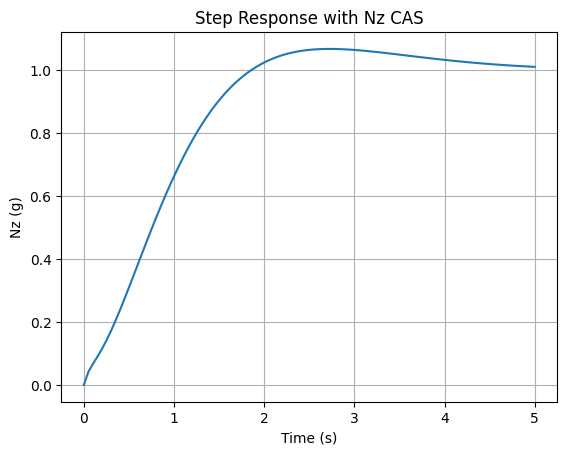

In [18]:
# create system (change Nz error to just Nz by negating C and zeroing D)
sys_final = ct.ss(A_c, g - sys_nz.B @ K_opt @ f, -sys_nz.C[E_IDX, :], np.array([[0]]))
t = np.linspace(0, 5, 100)
plt.figure()
tools.plot_step(sys_final, t, 'Nz (g)', 'Step Response with Nz CAS')